### TODOS
- Do analysis short vs. long sequences
- Length comparison how well does whisper legnth correlate with real length
- Are short sequences more often wrong than long sequences?
- F1 at predicting short sequences vs long sequences
- LLM with context
- fix space and casing issue

In [1]:
import pandas as pd
import os
from tqdm.auto import tqdm
from llm_asr_clarification.constants import SAMPLE_MEETINGS
import json
import torch
import torch.nn.functional as F
from rouge_score import rouge_scorer
from transformers import AutoTokenizer
from jiwer import wer


pd.set_option('display.max_colwidth', None)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   # or another causal LM
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

def rouge_l(pred, ref):
    return scorer.score(
        ref,   # reference first
        pred   # prediction second
    )["rougeL"]

def load_df_from_path(AMI_PATH):
    meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
        
    data = []
    for meeting_path in tqdm(meeting_paths):
        beam_results = os.path.join(meeting_path, "artifacts", f"beam_results.json")
        try:
            with open(beam_results, "r", encoding="utf-8") as f:
                lines = f.read()
            lines = json.loads(lines)
        except Exception as err:
            print(f"couldnt open file {beam_results}")
    
        for line in lines:
            for i in range(1,6):
                beam_no = f'beam_{i}'
                beam = line.pop(beam_no)
    
                line[f"{beam_no}_text"] = beam["text"]
                line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
                line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
                line[f"meeting_name"] = meeting_path.split("/")[-1]
                
    df = pd.DataFrame(lines)
    return df
    
AMI_TRAIN_PATH = '/group/jrwhitehill/amicorpus/train'
AMI_VAL_PATH = '/group/jrwhitehill/amicorpus/validation'

df = load_df_from_path(AMI_TRAIN_PATH)
df_val = load_df_from_path(AMI_VAL_PATH)

/home/pkongsomjit/miniconda3/envs/llm_clarification/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 18/18 [00:00<00:00, 128.66it/s]


In [2]:
df.head(3)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,meeting_name,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,beam_4_text,beam_4_asrlogprob,beam_4_llmlogprob,beam_5_text,beam_5_asrlogprob,beam_5_llmlogprob
0,Hello.,Hello,-0.499981,-16.62500,TS3006c,Hello.,-0.166628,-10.25000,Hello.,-0.166628,-10.2500,Hello.,-0.166628,-10.2500,Hello!,-0.749961,-9.25000
1,..,I need to go there.,-0.825584,-8.00000,TS3006c,I think we are going to need to go.,-1.653785,-5.71875,But I'm gonna throw the ball away.,-1.753428,-5.8750,the,-64.277092,-25.6250,I'm gonna get back to the hospital.,-0.878668,-6.37500
2,"Yes, I made it.","Yes, I made it.",-0.060835,-5.09375,TS3006c,"Yes, I made it.",-0.060835,-5.09375,Yes I made it,-0.627244,-7.4375,"Yes, I made it",-0.239422,-5.6875,"Yes, I made it.",-0.060835,-5.09375


In [3]:
def process_columns(df):
    llm_logprob_columns = [f'beam_{i}_llmlogprob' for i in range(1,6)]
    asr_logprob_columns = [f'beam_{i}_asrlogprob' for i in range(1,6)]
    
    llm_logprobs = torch.tensor(df[llm_logprob_columns].values)
    asr_logprobs = torch.tensor(df[asr_logprob_columns].values)
    
    # # ALL BEAMS
    # scores = F.softmax(ALPHA*llm_logprobs + 0.0asr_logprobs, dim=1)
    # highest_score_idxs = torch.argmax(scores, dim=1, keepdim=True)
    # highest_scores = torch.gather(scores, dim=1, index=highest_score_idxs)

    # JUST BEAM 1
    scores = llm_logprobs
    highest_scores = scores[torch.arange(scores.size(0)), torch.zeros(scores.size(0), dtype=torch.long)]


    # AGGREGATED STATS
    df['max_llmlogprobs'] = torch.max(llm_logprobs, dim=1).values.numpy()
    df['min_llmlogprobs'] = torch.min(llm_logprobs, dim=1).values.numpy()
    df['spread_llmlogprobs'] = df['max_llmlogprobs'] - df['min_llmlogprobs']

    df['max_asrlogprobs'] = torch.max(asr_logprobs, dim=1).values.numpy()
    df['min_asrlogprobs'] = torch.min(asr_logprobs, dim=1).values.numpy()
    df['spread_asrlogprobs'] = df['max_asrlogprobs'] - df['min_asrlogprobs']

    df['highest_score'] = highest_scores.numpy()
    
    df['text'] = df['beam_1_text']
    df['num_tokens_text'] = df['beam_1_text'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    df['num_tokens_gt'] = df['gt'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    
    
    df["rougeL"] = [
        rouge_l(pred, ref).fmeasure
        for pred, ref in zip(df["text"], df["gt"])
    ]
    df["wer"] = [
        min(1.0, wer(ref, pred))
        for pred, ref in zip(df["text"], df["gt"])
    ]

process_columns(df)
process_columns(df_val)

In [4]:
df.head(3)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,meeting_name,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,...,spread_llmlogprobs,max_asrlogprobs,min_asrlogprobs,spread_asrlogprobs,highest_score,text,num_tokens_text,num_tokens_gt,rougeL,wer
0,Hello.,Hello,-0.499981,-16.62500,TS3006c,Hello.,-0.166628,-10.25000,Hello.,-0.166628,...,7.37500,-0.166628,-0.749961,0.583333,-16.62500,Hello,2,3,1.0,1.0
1,..,I need to go there.,-0.825584,-8.00000,TS3006c,I think we are going to need to go.,-1.653785,-5.71875,But I'm gonna throw the ball away.,-1.753428,...,19.90625,-0.825584,-64.277092,63.451508,-8.00000,I need to go there.,7,2,0.0,1.0
2,"Yes, I made it.","Yes, I made it.",-0.060835,-5.09375,TS3006c,"Yes, I made it.",-0.060835,-5.09375,Yes I made it,-0.627244,...,2.34375,-0.060835,-0.627244,0.566409,-5.09375,"Yes, I made it.",7,7,1.0,0.0


# whisper text len vs. ground truth text len

In [5]:
import matplotlib.pyplot as plt

def corr_analysis(df, x='highest_score', y='rougeL'):
    df.plot.scatter(x=x, y=y)
    
    # Display the plot
    plt.show()
    
    from scipy.stats import pearsonr
    
    result = pearsonr(df[x], df[y])
    
    print(f"Pearson r: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")

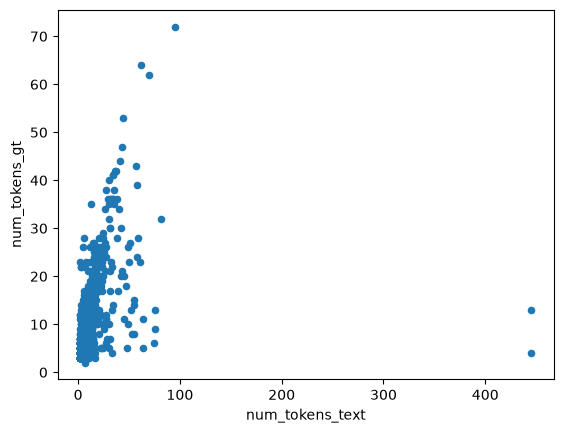

Pearson r: 0.3603
P-value: 0.0000


In [6]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

In [7]:
df = df[df['num_tokens_text'] < 400]
df_val = df_val[df_val['num_tokens_text'] < 400]

short_idx = df['num_tokens_text'] <= 5

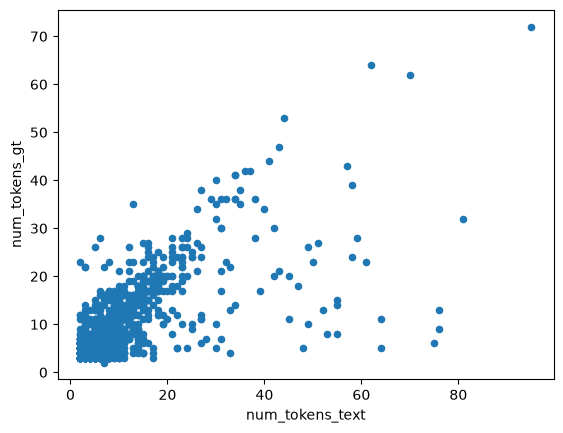

Pearson r: 0.7068
P-value: 0.0000


In [8]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

<Axes: >

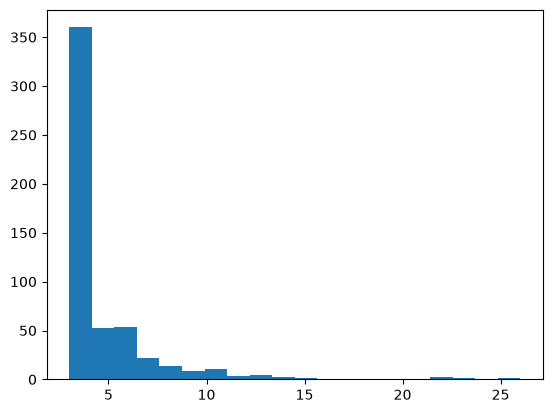

In [9]:
df[short_idx]['num_tokens_gt'].hist(bins=20, grid=False)

In [83]:
sum(short_idx)

537

In [84]:
sum((df['num_tokens_gt'] > df['num_tokens_text']))

628

In [81]:
sum((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))

369

In [88]:
len(df[((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))])/len(df[short_idx])

0.6871508379888268

In [89]:
len(df[((df['num_tokens_gt'] > 5) & (short_idx))])/len(df[short_idx])

0.2309124767225326

In [10]:
df[short_idx][['text','gt']].sample(10)

,text,gt
689,device again,And which which colour should uh should I give the the display?
275,OK.,Okay.
117,"Yeah, yeah",Yeah okay.
1059,you,Oh.
377,you,Distinction.
304,I'm just thinking,Too.
39,you,Yeah.
428,"So,",Also.
246,you,Yeah.
429,and,Yeah.


# errors analysis

In [11]:
df['wer'].describe()

count    1135.000000
mean        0.804697
std         0.297591
min         0.000000
25%         0.600000
50%         1.000000
75%         1.000000
max         1.000000
Name: wer, dtype: float64

In [12]:
df[['text','gt','wer','rougeL']].sample(5)

,text,gt,wer,rougeL
196,you,Yeah.,1.0,0.000000
459,you,Different.,1.0,0.000000
599,The,"So the keywords are primary co colours, spongey?",1.0,0.222222
959,you,Yeah.,1.0,0.000000
169,you,Yeah.,1.0,0.000000


In [13]:
sum(df['rougeL'] < 0.5)/len(df)

0.6325991189427312

In [14]:
sum(df['wer'] > 0.5)/len(df)

0.7876651982378855

In [15]:
short_idx = df['num_tokens_text'] <= 5

In [16]:
errors_rougeL_idx = df['rougeL'] < 0.5
errors_wer_idx = df['wer'] > 0.5

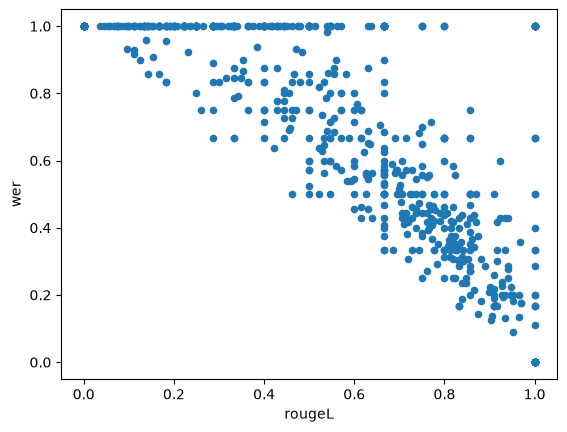

Pearson r: -0.8505
P-value: 0.0000


In [17]:
corr_analysis(df,'rougeL','wer')

<Axes: >

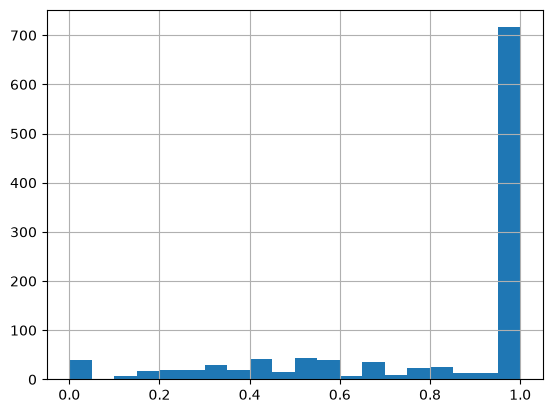

In [18]:
df['wer'].hist(bins=20)

In [19]:
df[errors_wer_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
627,I don't know what colors shoot the basic green be like like some green or something or a blue and then yeah dark blue and then should use them in very bright yellow banana and orange green apple stuff like that it's very Bright tones I guess yeah we need very primary colors like bright red bright yellow,"Yeah we could make We should use Yeah w we need very primary colours, like bright red, bright yellow.",0.329114,1.000000
513,That's for the LCD menu.,But you you want okay.,0.000000,1.000000
601,Spongebob.com,Spongey can be reached by means of Yeah.,0.000000,1.000000
643,that doesn't really work.,Huh cool.,0.000000,1.000000
955,what's up.,Why can't I work here?,0.000000,1.000000
181,She way you have to move.,Yeah.,0.000000,1.000000
118,Yeah. Yeah.,Yeah.,0.666667,1.000000
929,you,Yeah.,0.000000,1.000000
27,more done than last time.,Okay.,0.000000,1.000000
144,"it, which will be fun for toddlers.","Which will be fun for toddlers right, if they wanna use the And uh of course solar cells.",0.480000,0.833333


In [20]:
df[errors_rougeL_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
1023,up to there if you want.,Yeah.,0.000000,1.000000
978,maybe if it's easier if that's what I'm talking about.,Maybe I've uh it's easier if I draw it in once.,0.461538,0.727273
433,single curve then.,Yeah that would be an option.,0.000000,1.000000
1058,you,Yeah.,0.000000,1.000000
784,this sermon night even for colorblind.,Even for colourblind.,0.444444,1.000000
1129,you,I dunno.,0.000000,1.000000
351,you,Yeah.,0.000000,1.000000
1025,yeah.,But we still keep the flipping mechanism.,0.000000,1.000000
830,you,Alright.,0.000000,1.000000
1108,"Yeah, yeah, how's that?",I don't see any power cables here so 'Kay.,0.000000,1.000000


In [21]:
df[errors_wer_idx][['text','gt']].sample(10)

,text,gt
506,Thanks for watching!,Right.
349,you,Yeah perfect.
803,cooler. Okay.,Okay.
434,I'd have been watching that with you things.,I don't know what you think.
185,the ability,Yeah.
494,"No, like I wouldn't",No uh like I would draw it like this.
535,you,Exactly.
162,materials.,"Well we have all kinds of hard uh materials like the the hard plastic, the wood and the titanium."
230,presence.,Okay.
919,I don't know.,Oh no it's it's okay.


In [22]:
print(df['rougeL'].describe())
rougeL_fifty = df['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")
rougeL_twentyfive = df['rougeL'].quantile(0.25)
print(f"25th quartile for rougeL is: {rougeL_twentyfive:.2f}")

count    1135.000000
mean        0.332355
std         0.362843
min         0.000000
25%         0.000000
50%         0.181818
75%         0.666667
max         1.000000
Name: rougeL, dtype: float64
50th quartile for rougeL is: 0.18
25th quartile for rougeL is: 0.00


In [23]:
errors_idx = errors_rougeL_idx

In [24]:
p_error = len(df[errors_idx])/len(df)
print(f"P(error) = {p_error:.3f}")
p_short = len(df[short_idx])/len(df)
print(f"P(short) = {p_short:.3f}")

p_error_given_short = len(df[(short_idx) & (errors_idx)]) / len(df[short_idx])
print(f"P(error|short) = {p_error_given_short:.3f}")

p_error_given_long = len(df[(~short_idx) & (errors_idx)]) / len(df[~short_idx])
print(f"P(error|long) = {p_error_given_long:.3f}")

p_short_given_error = len(df[(short_idx) & (errors_idx)]) / len(df[errors_idx])
print(f"P(short|error) = {p_short_given_error:.3f}")
print(f"P(long|error) = {1-p_short_given_error:.3f}")

P(error) = 0.633
P(short) = 0.473
P(error|short) = 0.808
P(error|long) = 0.475
P(short|error) = 0.604
P(long|error) = 0.396


In [25]:
from statsmodels.stats.proportion import proportions_ztest

# Number of errors in each group
n_errors_short = ((short_idx) & (errors_idx)).sum()
n_errors_long = ((~short_idx) & (errors_idx)).sum()

# Number of samples in each group
n_short = short_idx.sum()
n_long = (~short_idx).sum()

# Two-proportion z-test
count = [n_errors_short, n_errors_long]
nobs = [n_short, n_long]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Short error rate: {n_errors_short/n_short:.3f}")
print(f"Long error rate:  {n_errors_long/n_long:.3f}")
print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.6f}")

Short error rate: 0.808
Long error rate:  0.475
z = 11.628
p = 0.000000


# filtering for actual long utterances

<Axes: >

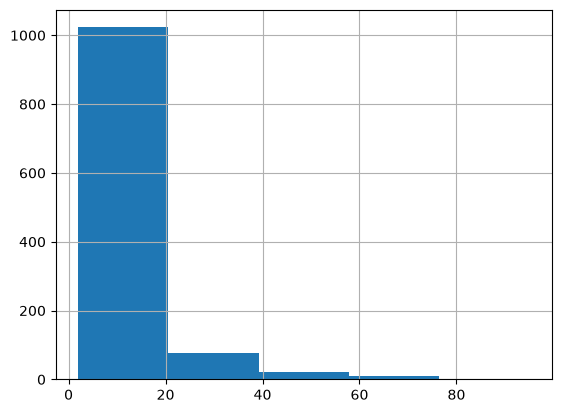

In [26]:
df['num_tokens_text'].hist(bins=5)

In [27]:
# Filter out for only actual phrases not just 'ummm' and 'ahhh' and 'yeahh'
longs_df = df[~short_idx]
shorts_df = df[short_idx]

In [28]:
# min_score = min(df['highest_score'])
# range_score = max(df['highest_score']) - min_score
# df['normalized_score'] = (df['highest_score'] - min_score)/range_score

# def standardize_df(datfram):
#     datfram['normalized_score'] = (
#         datfram['highest_score'] - datfram['highest_score'].mean()
#     )/datfram['highest_score'].std()

# standardize_df(df)
# standardize_df(shorts_df)
# standardize_df(longs_df)

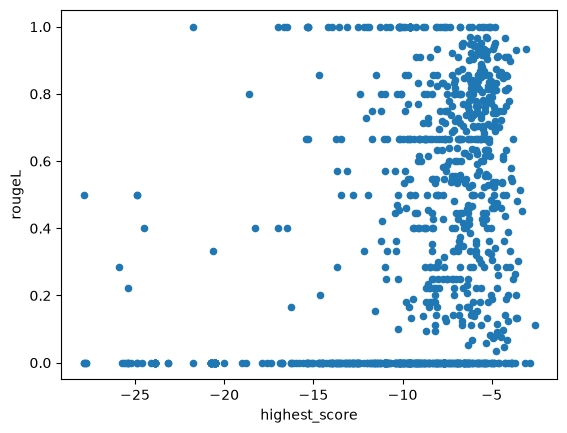

Pearson r: 0.4827
P-value: 0.0000


In [29]:
corr_analysis(df)

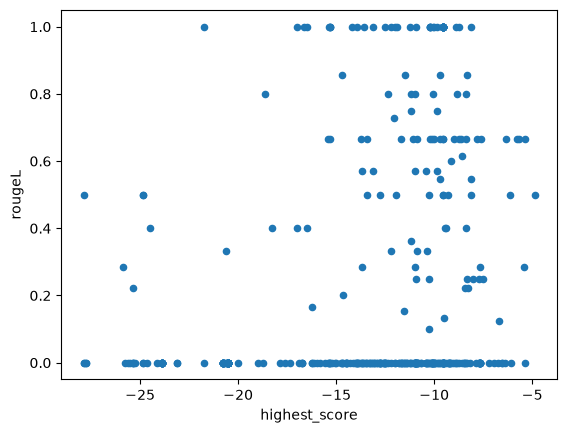

Pearson r: 0.3787
P-value: 0.0000


In [30]:
corr_analysis(shorts_df)

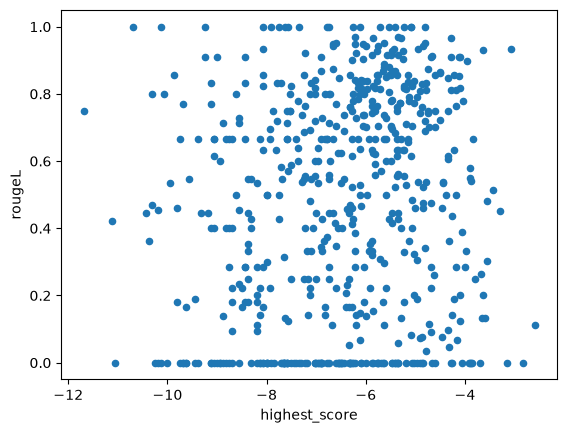

Pearson r: 0.1319
P-value: 0.0012


In [31]:
corr_analysis(longs_df)

<Axes: >

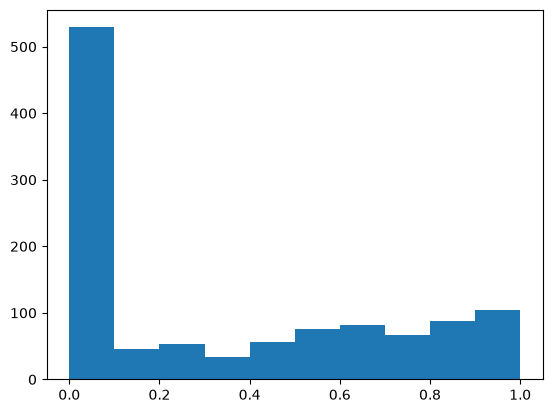

In [32]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

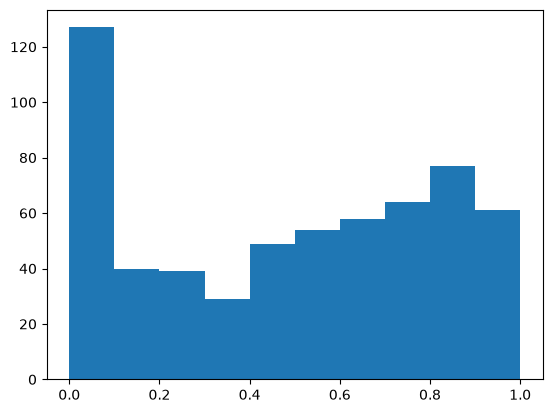

In [33]:
longs_df['rougeL'].hist(grid=False, bins=10)

<Axes: >

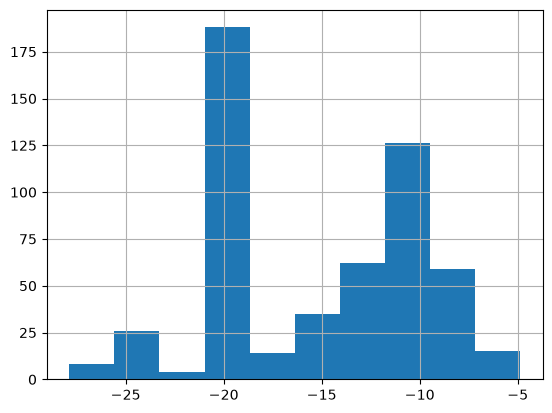

In [34]:
shorts_df['highest_score'].hist()

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["highest_score", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["highest_score"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []

    roc_auc = roc_auc_score(y_true, -df["highest_score"])
    
    for thresh in thresholds:
        y_pred = (
            (df["highest_score"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"ROCAUC: {roc_auc}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [36]:
pd.set_option('display.max_colwidth', None)

Best threshold: -6.1666
ROCAUC: 0.738871298504372
Best F1: 0.7761
Precision at best F1: 0.7194
Recall at best F1: 0.8426



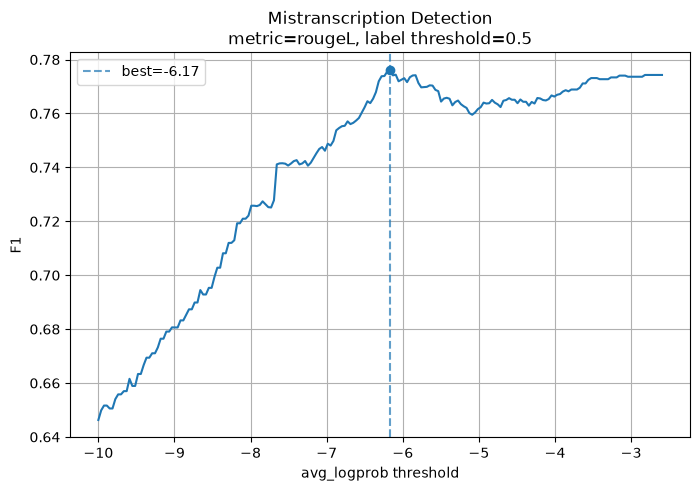

In [37]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -2.8171
ROCAUC: 0.5746781645285727
Best F1: 0.6425
Precision at best F1: 0.4740
Recall at best F1: 0.9965



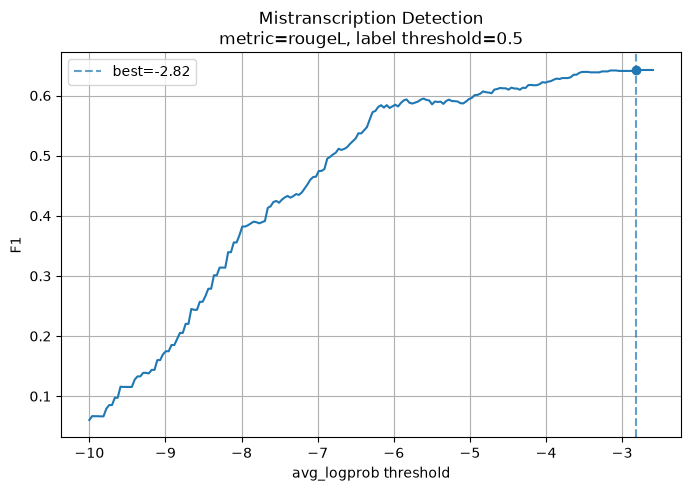

In [38]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -7.5809
ROCAUC: 0.7963235522434406
Best F1: 0.7314
Precision at best F1: 0.6736
Recall at best F1: 0.8000



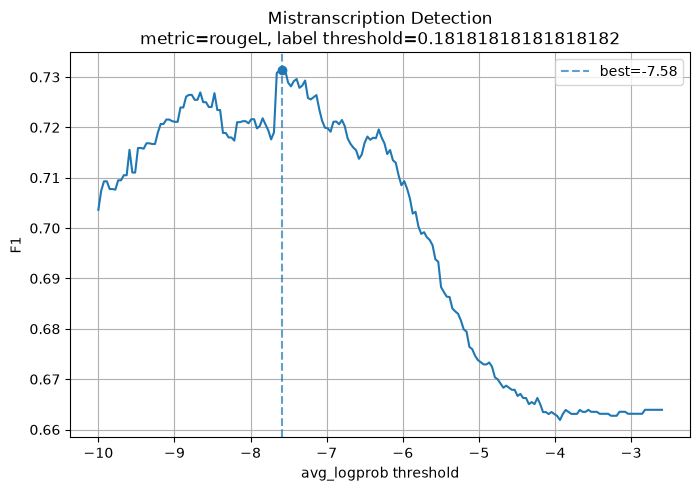

In [39]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

Best threshold: -6.0922
ROCAUC: 0.5610687571921749
Best F1: 0.4189
Precision at best F1: 0.3100
Recall at best F1: 0.6456



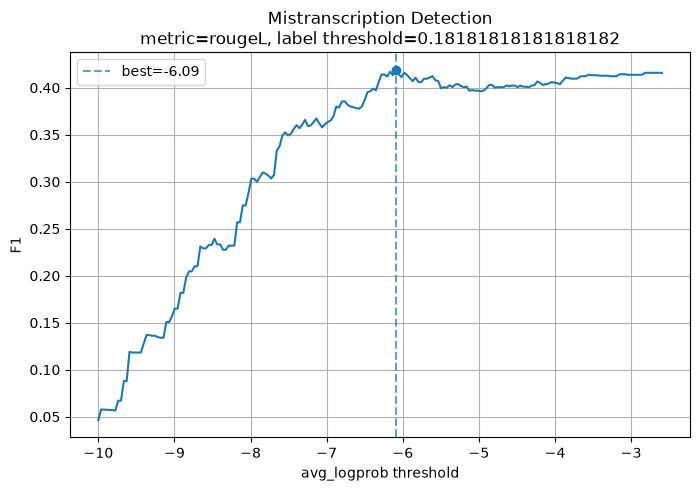

In [40]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

# ml stuff

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df['y_true'] = errors_idx
df_val['y_true'] = df_val['rougeL'] < 0.5

FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
]

def train_and_eval_rf(FEATURES):
    TARGET = "y_true"
    
    # --------------------
    # Train RF
    # --------------------
    
    X_train = df[FEATURES]
    y_train = df[TARGET].astype(int)
    
    X_val = df_val[FEATURES]
    y_val = df_val[TARGET].astype(int)
    
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=30,
        random_state=42,
        n_jobs=-1,
    )
    
    rf.fit(X_train, y_train)
    
    # --------------------
    # Predictions
    # --------------------
    
    train_probs = rf.predict_proba(X_train)[:, 1]
    val_probs = rf.predict_proba(X_val)[:, 1]
    
    # --------------------
    # Overall AUROC
    # --------------------
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(f"Train AUROC: {train_auc:.4f}")
    print(f"Val   AUROC: {val_auc:.4f}")
    
    # --------------------
    # Short / Long subsets
    # --------------------
    
    train_shorts_idx = df["num_tokens_text"] <= 5
    val_shorts_idx = df_val["num_tokens_text"] <= 5
    
    def subset_auc(y, probs, mask):
        if y[mask].nunique() < 2:
            return float("nan")
        return roc_auc_score(y[mask], probs[mask])
    
    print("\nTRAIN")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_train, train_probs, train_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_train, train_probs, ~train_shorts_idx):.4f}"
    )
    
    print("\nVALIDATION")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_val, val_probs, val_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_val, val_probs, ~val_shorts_idx):.4f}"
    )


    def elbow_plot(
        y_true,
        scores,
        threshold_range=None,
        n_thresholds=200,
    ):
        """
        Finds the threshold maximizing F1.
    
        Parameters
        ----------
        y_true : array-like of bool/int
            Ground truth labels (1 = error).
    
        scores : array-like
            Probability or score where LARGER means MORE likely to be an error.
    
        threshold_range : (min, max) or None
            Threshold search range. Defaults to score min/max.
    
        Returns
        -------
        best_threshold, best_f1, best_precision, best_recall
        """
    
        y_true = np.asarray(y_true).astype(int)
        scores = np.asarray(scores)
    
        if threshold_range is None:
            tmin = scores.min()
            tmax = scores.max()
        else:
            tmin, tmax = threshold_range
    
        thresholds = np.linspace(tmin, tmax, n_thresholds)
    
        f1s = []
        precisions = []
        recalls = []
    
        for t in thresholds:
            pred = scores >= t
    
            precisions.append(
                precision_score(y_true, pred, zero_division=0)
            )
            recalls.append(
                recall_score(y_true, pred, zero_division=0)
            )
            f1s.append(
                f1_score(y_true, pred, zero_division=0)
            )
    
        f1s = np.array(f1s)
        precisions = np.array(precisions)
        recalls = np.array(recalls)
    
        best_idx = np.argmax(f1s)
    
        best_threshold = thresholds[best_idx]
        best_f1 = f1s[best_idx]
        best_precision = precisions[best_idx]
        best_recall = recalls[best_idx]
    
        plt.figure(figsize=(7,4))
        plt.plot(thresholds, f1s, label="F1")
        plt.plot(thresholds, precisions, label="Precision")
        plt.plot(thresholds, recalls, label="Recall")
    
        plt.axvline(
            best_threshold,
            linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}",
        )
    
        plt.xlabel("Threshold")
        plt.ylabel("Metric")
        plt.title("Threshold selection")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Best F1:        {best_f1:.4f}")
        print(f"Precision:      {best_precision:.4f}")
        print(f"Recall:         {best_recall:.4f}")

    val_probs = rf.predict_proba(X_val)[:, 1]
    elbow_plot(y_val[~val_shorts_idx], val_probs[~val_shorts_idx])

    return rf

Train AUROC: 0.8052
Val   AUROC: 0.7311

TRAIN
Short AUROC: 0.8210
Long  AUROC: 0.7208

VALIDATION
Short AUROC: 0.7958
Long  AUROC: 0.5868


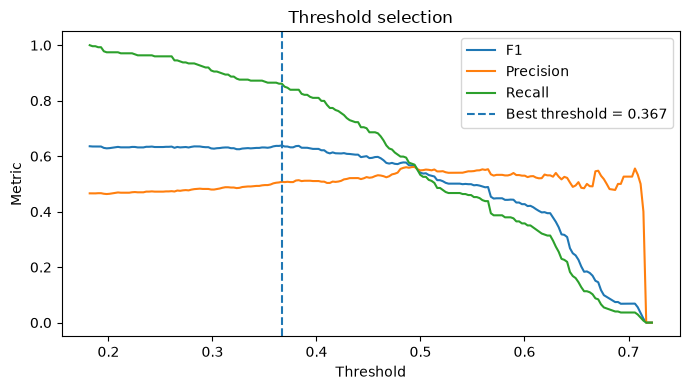

Best threshold: 0.3667
Best F1:        0.6387
Precision:      0.5075
Recall:         0.8613


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [68]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.8558
Val   AUROC: 0.7891

TRAIN
Short AUROC: 0.8515
Long  AUROC: 0.8148

VALIDATION
Short AUROC: 0.8341
Long  AUROC: 0.7021


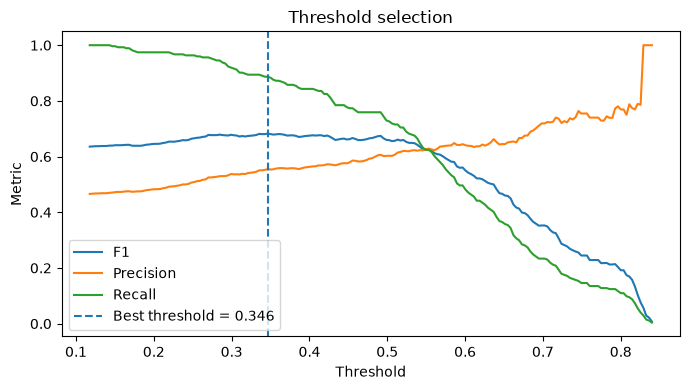

Best threshold: 0.3463
Best F1:        0.6826
Precision:      0.5548
Recall:         0.8869


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [69]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob"
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.8701
Val   AUROC: 0.8047

TRAIN
Short AUROC: 0.8665
Long  AUROC: 0.8400

VALIDATION
Short AUROC: 0.8349
Long  AUROC: 0.7373


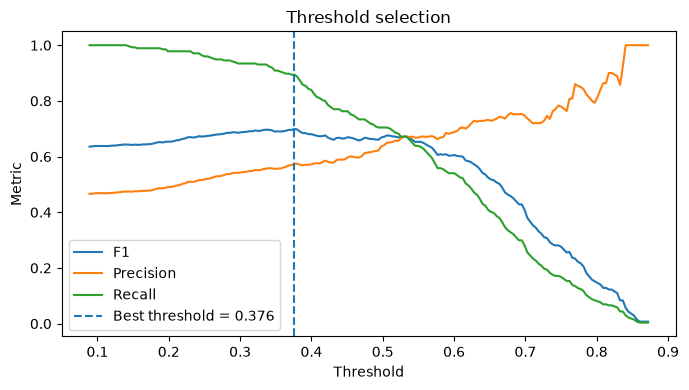

Best threshold: 0.3762
Best F1:        0.6990
Precision:      0.5738
Recall:         0.8942


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [70]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.8731
Val   AUROC: 0.8149

TRAIN
Short AUROC: 0.8754
Long  AUROC: 0.8392

VALIDATION
Short AUROC: 0.8486
Long  AUROC: 0.7499


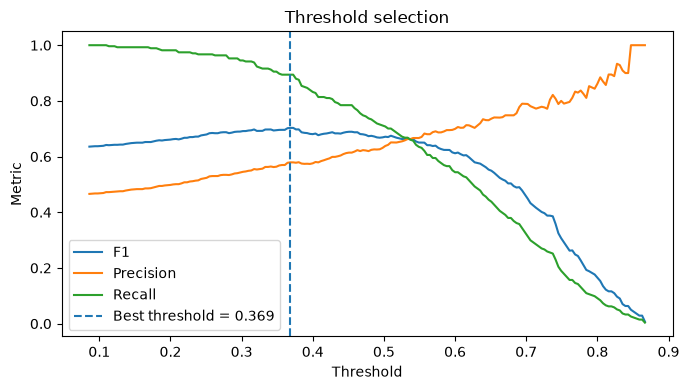

Best threshold: 0.3685
Best F1:        0.7030
Precision:      0.5792
Recall:         0.8942


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [71]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.8726
Val   AUROC: 0.8143

TRAIN
Short AUROC: 0.8727
Long  AUROC: 0.8376

VALIDATION
Short AUROC: 0.8482
Long  AUROC: 0.7466


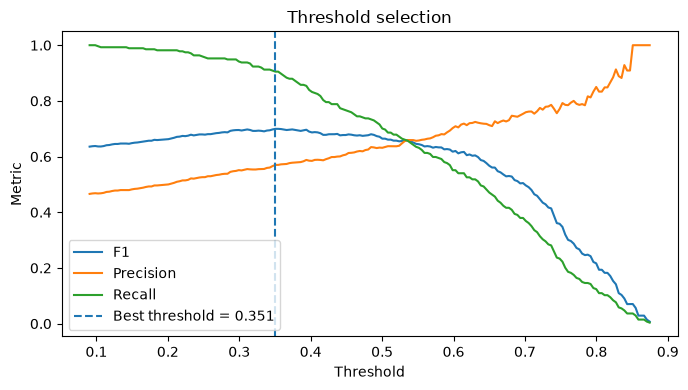

Best threshold: 0.3505
Best F1:        0.6996
Precision:      0.5701
Recall:         0.9051


In [72]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
rf = train_and_eval_rf(FEATURES)